# Heart Disease Prediction with K-Nearest Neighbors (KNN)

## Project Overview
This project focuses on predicting the likelihood of heart disease using a **K-Nearest Neighbors (KNN)** classification model trained on the **UCI Heart Disease Dataset**. The dataset contains clinical and demographic features such as age, sex, chest pain type, blood pressure, cholesterol levels, ECG results, maximum heart rate, exercise-induced angina, and other cardiovascular indicators used to determine whether a patient is at risk of heart disease. This notebook covers the complete machine learning workflow including data exploration, preprocessing, encoding categorical variables, feature scaling, train-test splitting, model training, hyperparameter tuning for the optimal value of `k` and `metric`, and evaluation using accuracy scores, confusion matrix, and other classification metrics. Since KNN is a distance-based algorithm, proper feature scaling was applied to improve prediction performance and ensure balanced influence across all features. The goal of this project is to **demonstrate how machine learning can support early detection of cardiovascular disease** and contribute to more informed healthcare decision-making.

### Import Required Libraries

In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score

%matplotlib inline


### Load the Dataset

In [270]:
heart_df = pd.read_csv('heart.csv')
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Exploratory Data Analysis [EDA]

In [271]:
# Pay attention to the min values of RestingBP & Cholesterol
heart_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [272]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Explore the non-numeric variables

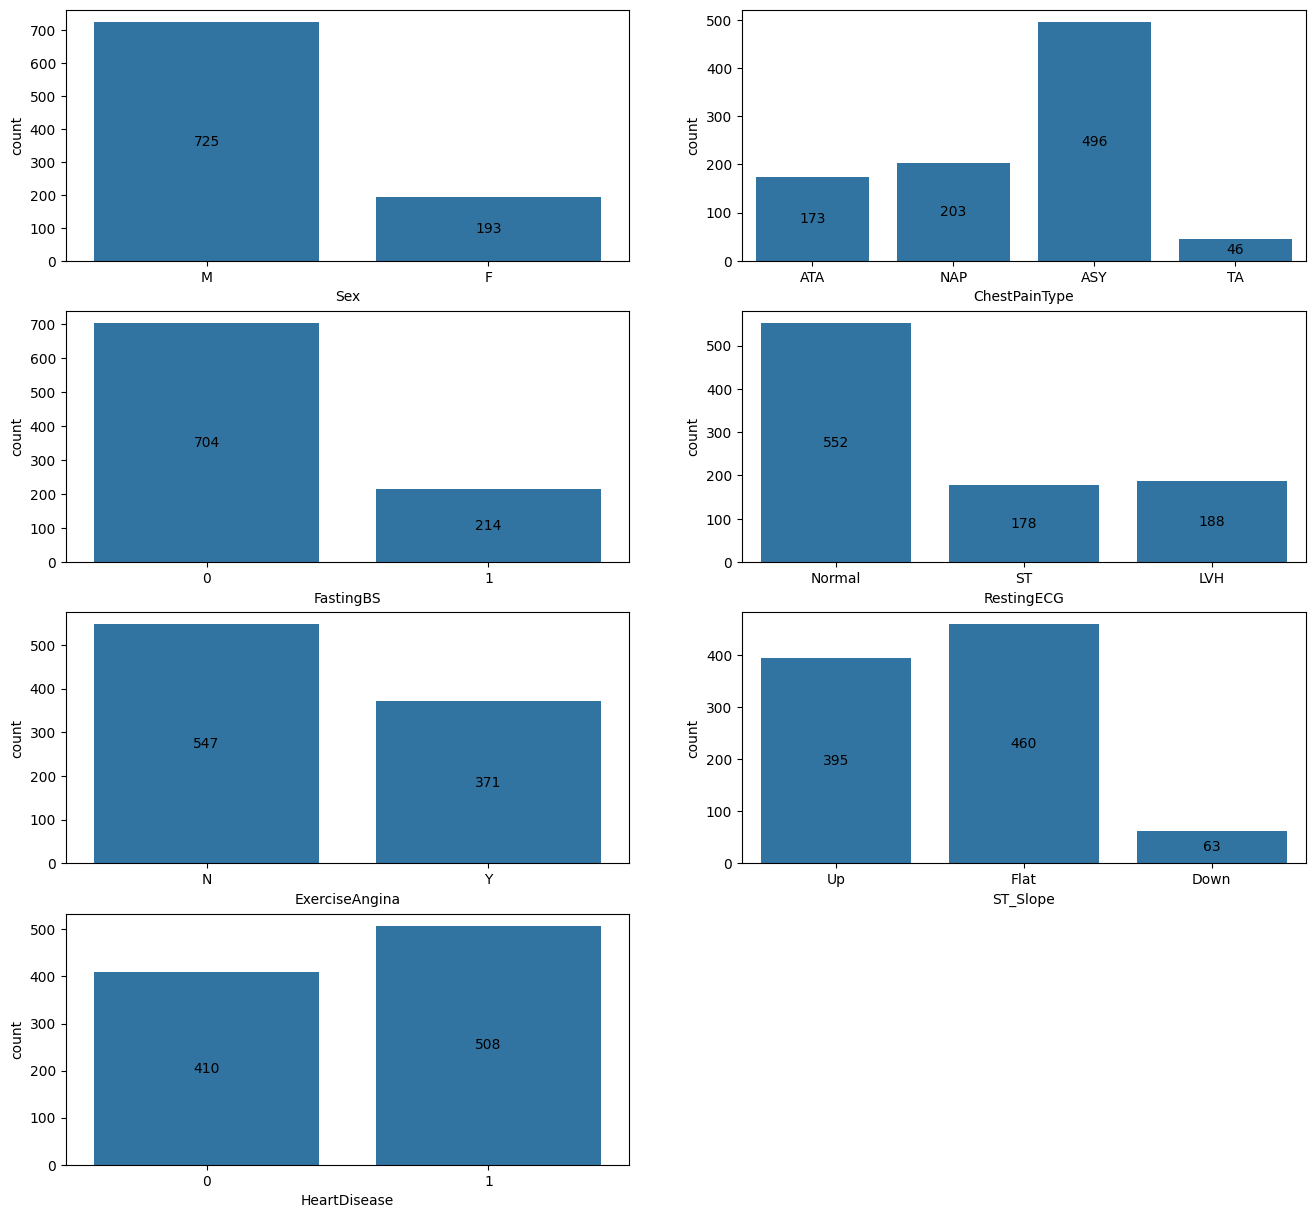

In [273]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

fig = plt.figure(figsize=(16, 15))

for idx, col in enumerate(categorical_cols, start=1):
    ax = plt.subplot(4, 2, idx)
    sns.countplot(x=heart_df[col], ax=ax)
    # Adding data labels to each bar
    for container in ax.containers:
        ax.bar_label(container, label_type='center')
        
plt.show()

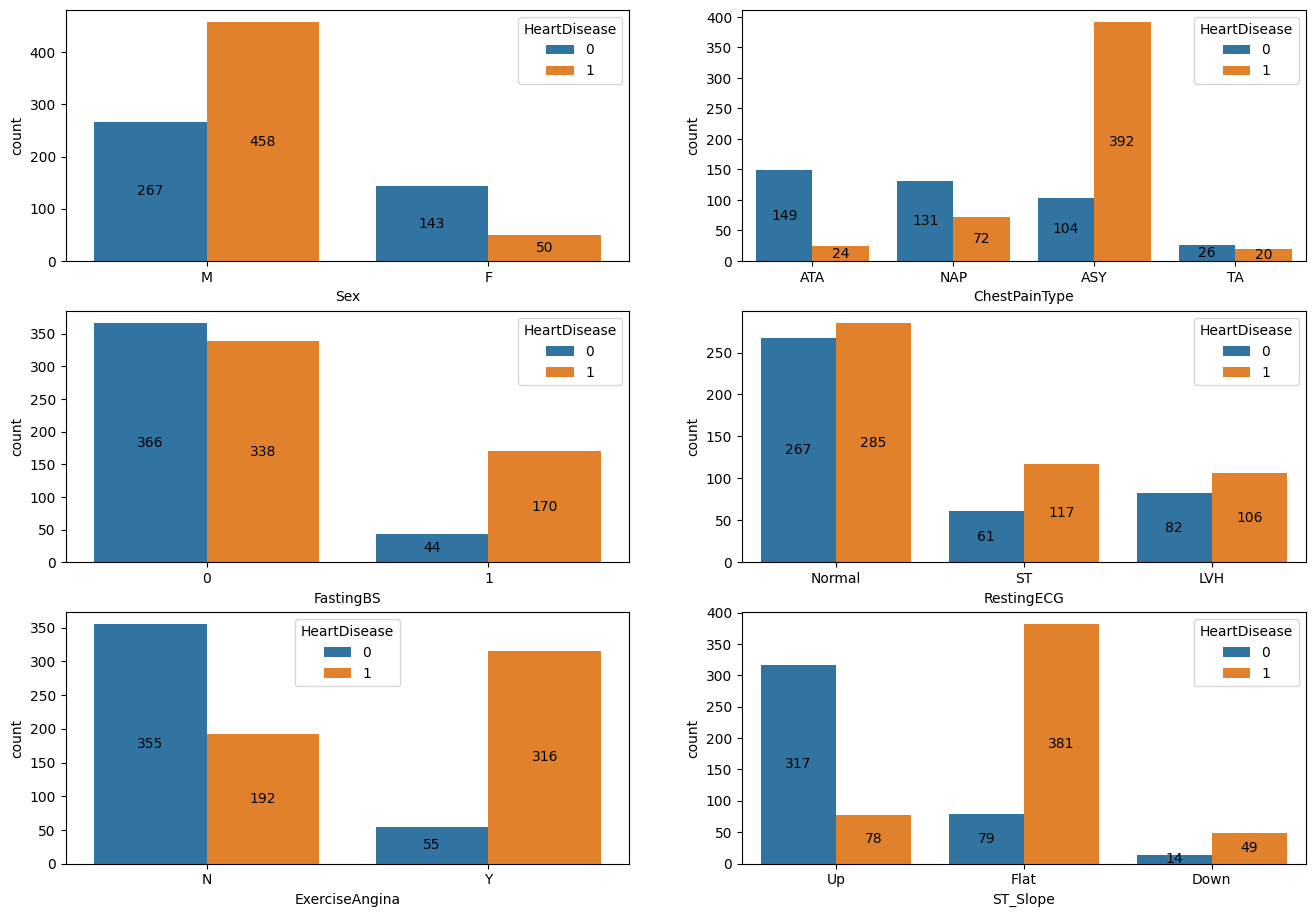

In [274]:
# Group each categorical column by heart disease status
fig = plt.figure(figsize=(16, 15))

for idx, col in enumerate(categorical_cols[:-1], start=1):
    ax = plt.subplot(4, 2, idx)
    
    # group by HeartDisease
    sns.countplot(x=heart_df[col], hue=heart_df['HeartDisease'], ax=ax)
    
    # add data labels to each bar using matplotlib.container
    for container in ax.containers:
        ax.bar_label(container=container, label_type='center')

### Check the number of observations with RestingBP of 0

In [275]:
len(heart_df[heart_df['RestingBP']==0])

1

### Check the number of observations with Cholesterol level of 0

In [276]:
len(heart_df[heart_df['Cholesterol']==0])

172

## Data Cleaning

In [277]:
# Create a copy of the dataframe
df_clean = heart_df.copy()

# Drop the single impossible RestingBP artifact
df_clean = df_clean[df_clean['RestingBP'] != 0]

### Target-Stratified Imputation of Missing Cholesterol Values

In [278]:
# Temporarily convert cholesterol values of 0 to NaN so they're exccluded from the median calculations
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)

# Compute and apply group-specific medians
df_clean['Cholesterol'] = df_clean.groupby('HeartDisease')['Cholesterol'].transform(lambda x: x.fillna(x.median()))

In [279]:
#  Check the new median values of RestingBP and Cholesterol
df_clean[['RestingBP', 'Cholesterol']].describe()

,RestingBP,Cholesterol
count,917.000000,917.000000
mean,132.540894,244.573610
std,17.999749,53.385261
min,80.000000,85.000000
25%,120.000000,214.000000
50%,130.000000,246.000000
75%,140.000000,267.000000
max,200.000000,603.000000


### Correlation Analysis

In [280]:
# One-Hot Encoding: Convert categorical variables to numeric dummy columns for correlation analysis
df_clean = pd.get_dummies(df_clean, drop_first=True)
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [281]:
df_clean.shape

(917, 16)

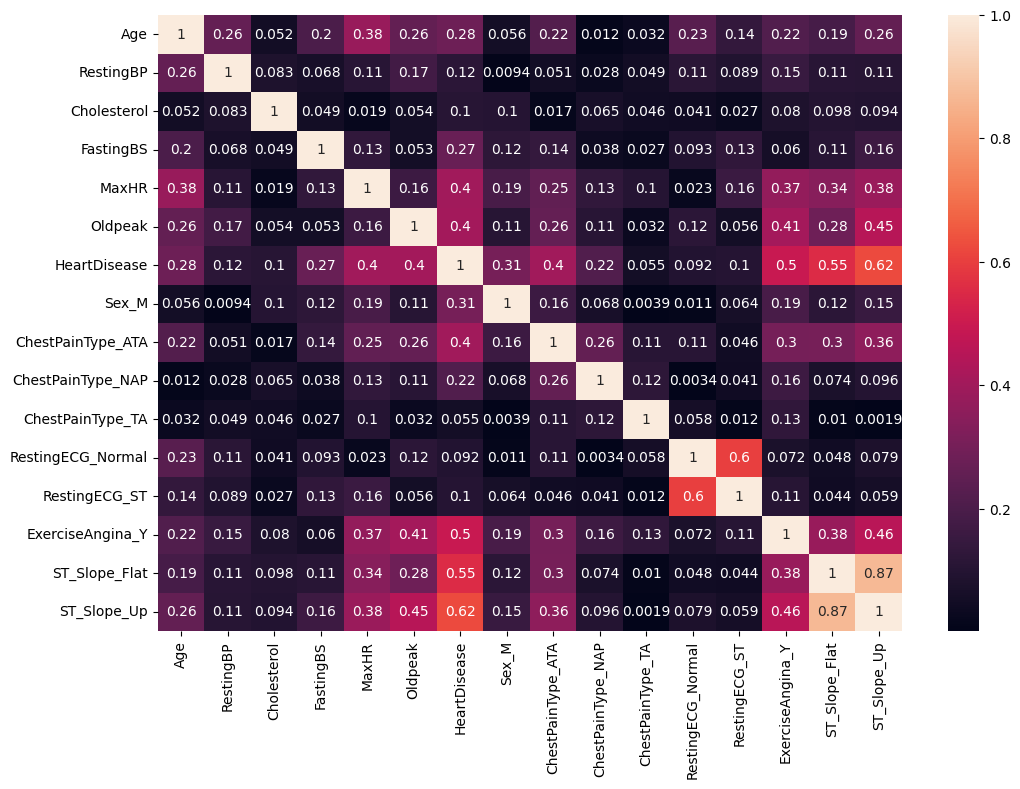

In [282]:
correlations = abs(df_clean.corr())
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, annot=True, cmap='rocket')
plt.show()

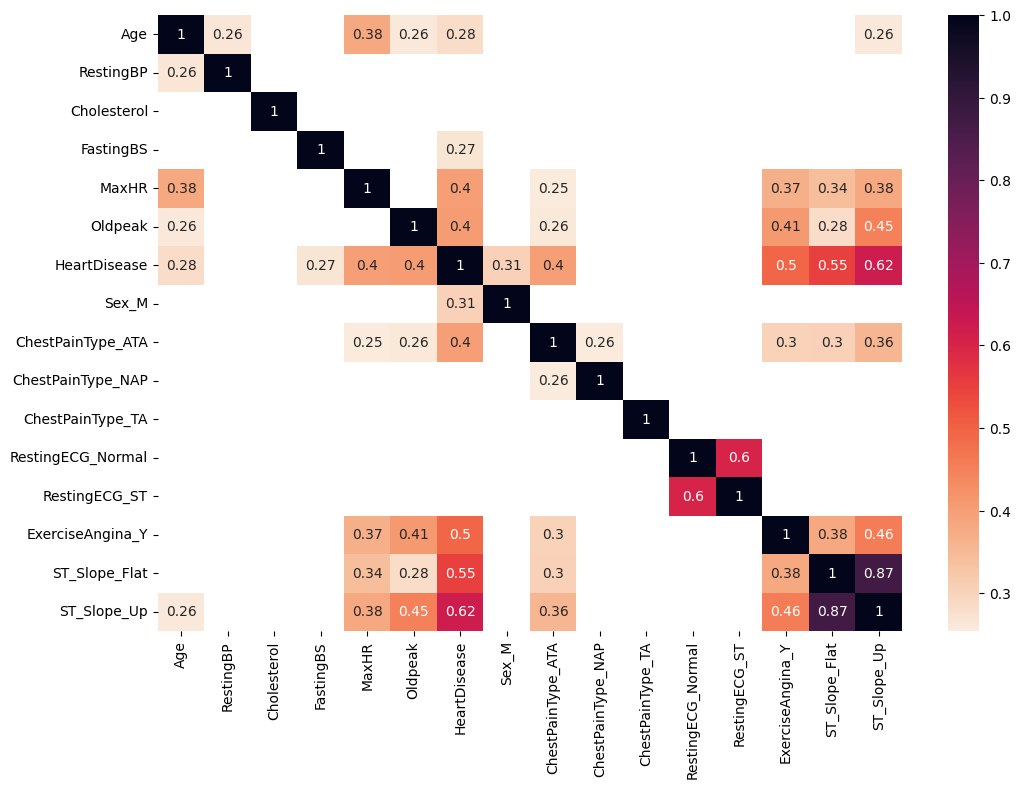

In [283]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlations[correlations > 0.25], annot=True, cmap='rocket_r')
plt.show()

## Training the Model

In [284]:
X = df_clean.drop('HeartDisease', axis=1)
y = df_clean.HeartDisease

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=111)

# Obtained from the correlation matrix above
features = [
    'Age',
    'MaxHR',
    'Oldpeak',
    'Sex_M',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

for feature in features:
    k = 3
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train[[feature]], y_train)
    accuracy = knn.score(X_test[[feature]], y_test)
    print(f"The k-NN classifier trained on {feature} and with k = {k} has an accuracy {accuracy*100:.2f}%")

The k-NN classifier trained on Age and with k = 3 has an accuracy 50.00%
The k-NN classifier trained on MaxHR and with k = 3 has an accuracy 60.87%
The k-NN classifier trained on Oldpeak and with k = 3 has an accuracy 67.93%
The k-NN classifier trained on Sex_M and with k = 3 has an accuracy 40.22%
The k-NN classifier trained on ExerciseAngina_Y and with k = 3 has an accuracy 70.65%
The k-NN classifier trained on ST_Slope_Flat and with k = 3 has an accuracy 79.35%
The k-NN classifier trained on ST_Slope_Up and with k = 3 has an accuracy 83.15%


### Feature Scaling (and training w/o hyperparam tuning)

In [285]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_test_scaled = scaler.transform(X_test[features])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 82.07%


### Hyperparameter Tuning

In [286]:
grid_params = {
    'n_neighbors' : range(1, 21),
    'metric' : ['euclidean', 'minkowski', 'manhattan']
}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'minkowski', ...], 'n_neighbors': range(1, 21)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [287]:
knn_grid.best_score_*100, knn_grid.best_params_

(np.float64(84.45624825272574), {'metric': 'manhattan', 'n_neighbors': 9})

### Model Evaluation

In [288]:
# Evaluation metric: Accuracy
X_test_scaled = scaler.transform(X_test[features])
predictions = knn_grid.best_estimator_.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print(f" Model Accuracy on test set: {accuracy*100:.2f}%")

 Model Accuracy on test set: 83.15%


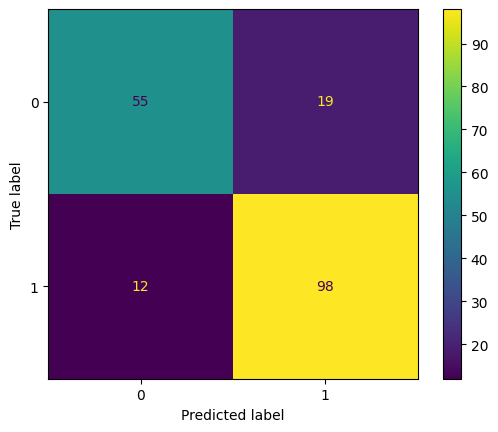

In [289]:
# Evaluation metric: Confusion matrix
cf = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cf).plot()
plt.show()

In [293]:
# Evaluation metric: Recall
recall = recall_score(y_test, predictions)
print(f"{recall*100:.2f}%")

89.09%
